# Dataset and research design

**Objective.** Predict the correctness of a learner's response to a mathematics question using only information available before that completed response.

**Unit of analysis:** one AnswerId; learners and questions induce dependence. The full source is described separately from the identifier-selected experimental cohort. This is retrospective validation on a previously studied source, not an untouched confirmatory dataset.

**Inputs:** the official local Eedi response and metadata files. **Next stage:** chronological feature construction in Notebook 02. No model is selected from the descriptive distributions below.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions():
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    return pd.concat([pd.read_parquet(path) for path in paths], ignore_index=True)


## Source population and eligibility
The activity threshold is checked on the actual source. It cannot establish performance for learners excluded before the supplied dataset was assembled.

In [3]:
with capture_output():
    rd.raw_prerequisites()
    source_population = rd.population_and_protocol()
show_table(source_population, "Source population and the ≥20-response rule", ["population"])

**Source population and the ≥20-response rule**

population,interactions,students,questions,prevalence,student_min
raw,15867850,118971,27613,0.64295,29
eligible_ge20,15867850,118971,27613,0.64295,29


population,student_Q1,student_median,student_Q3,student_IQR,question_median
raw,57,88,159,102,281
eligible_ge20,57,88,159,102,281


population,question_fraction_le5,question_fraction_le10,question_fraction_le20,unique_pairs
raw,0,0,0,15867850
eligible_ge20,0,0,0,15867850


## Experimental cohort and question sparsity
The learner inclusion rule uses hashed identifiers, not response correctness or future activity length. Counts below characterize the full selected cohort; they are not an additional validation sample.

In [3]:
events = pd.read_parquet(artifact_path("Data") / ("events_" + rd.protocol()["cohort"]["salt"] + ".parquet")) if (artifact_path("Data") / ("events_" + rd.protocol()["cohort"]["salt"] + ".parquet")).exists() else None
if events is None:
    rd.load_events()
    events = pd.read_parquet(artifact_path("Data") / ("events_" + rd.protocol()["cohort"]["salt"] + ".parquet"))
question_counts = events.groupby("QuestionId").size()
learner_counts = events.groupby("UserId").size()
cohort = pd.DataFrame([{
    "Interactions": len(events), "Learners": events.UserId.nunique(),
    "Questions": len(question_counts), "Correct response fraction": events.IsCorrect.mean(),
    "Duplicate AnswerId": int(events.AnswerId.duplicated().sum()),
    "Missing completion timestamps": int(events.DateAnswered.isna().sum()),
    "Missing primary subject": int(events.primary_subject_id.isna().sum()),
    "Missing parent subject": int(events.parent_subject_id.isna().sum())}])
show_table(cohort, "Identifier-selected experimental population")
qsummary = pd.DataFrame([{"Minimum":question_counts.min(), "Q1":question_counts.quantile(.25),
    "Median":question_counts.median(), "Q3":question_counts.quantile(.75),
    "IQR":question_counts.quantile(.75)-question_counts.quantile(.25), "Maximum":question_counts.max(),
    "Questions ≤5":int((question_counts<=5).sum()), "Fraction ≤5":(question_counts<=5).mean(),
    "Questions ≤10":int((question_counts<=10).sum()), "Fraction ≤10":(question_counts<=10).mean(),
    "Questions ≤20":int((question_counts<=20).sum()), "Fraction ≤20":(question_counts<=20).mean()}])
show_table(qsummary, "Response support per question")

**Identifier-selected experimental population**

Interactions,Learners,Questions,Correct response fraction,Duplicate AnswerId
385037,2904,25899,0.642393,0


Missing completion timestamps,Missing primary subject,Missing parent subject
0,0,0


**Response support per question**

Minimum,Q1,Median,Q3,IQR
1,3,8,22,19


Maximum,Questions ≤5,Fraction ≤5,Questions ≤10,Fraction ≤10
157,10785,0.416425,14626,0.564732


Questions ≤20,Fraction ≤20
18799,0.725858


### Distribution of question support
The empirical cumulative distribution describes sparsity over questions, with each question receiving equal weight.

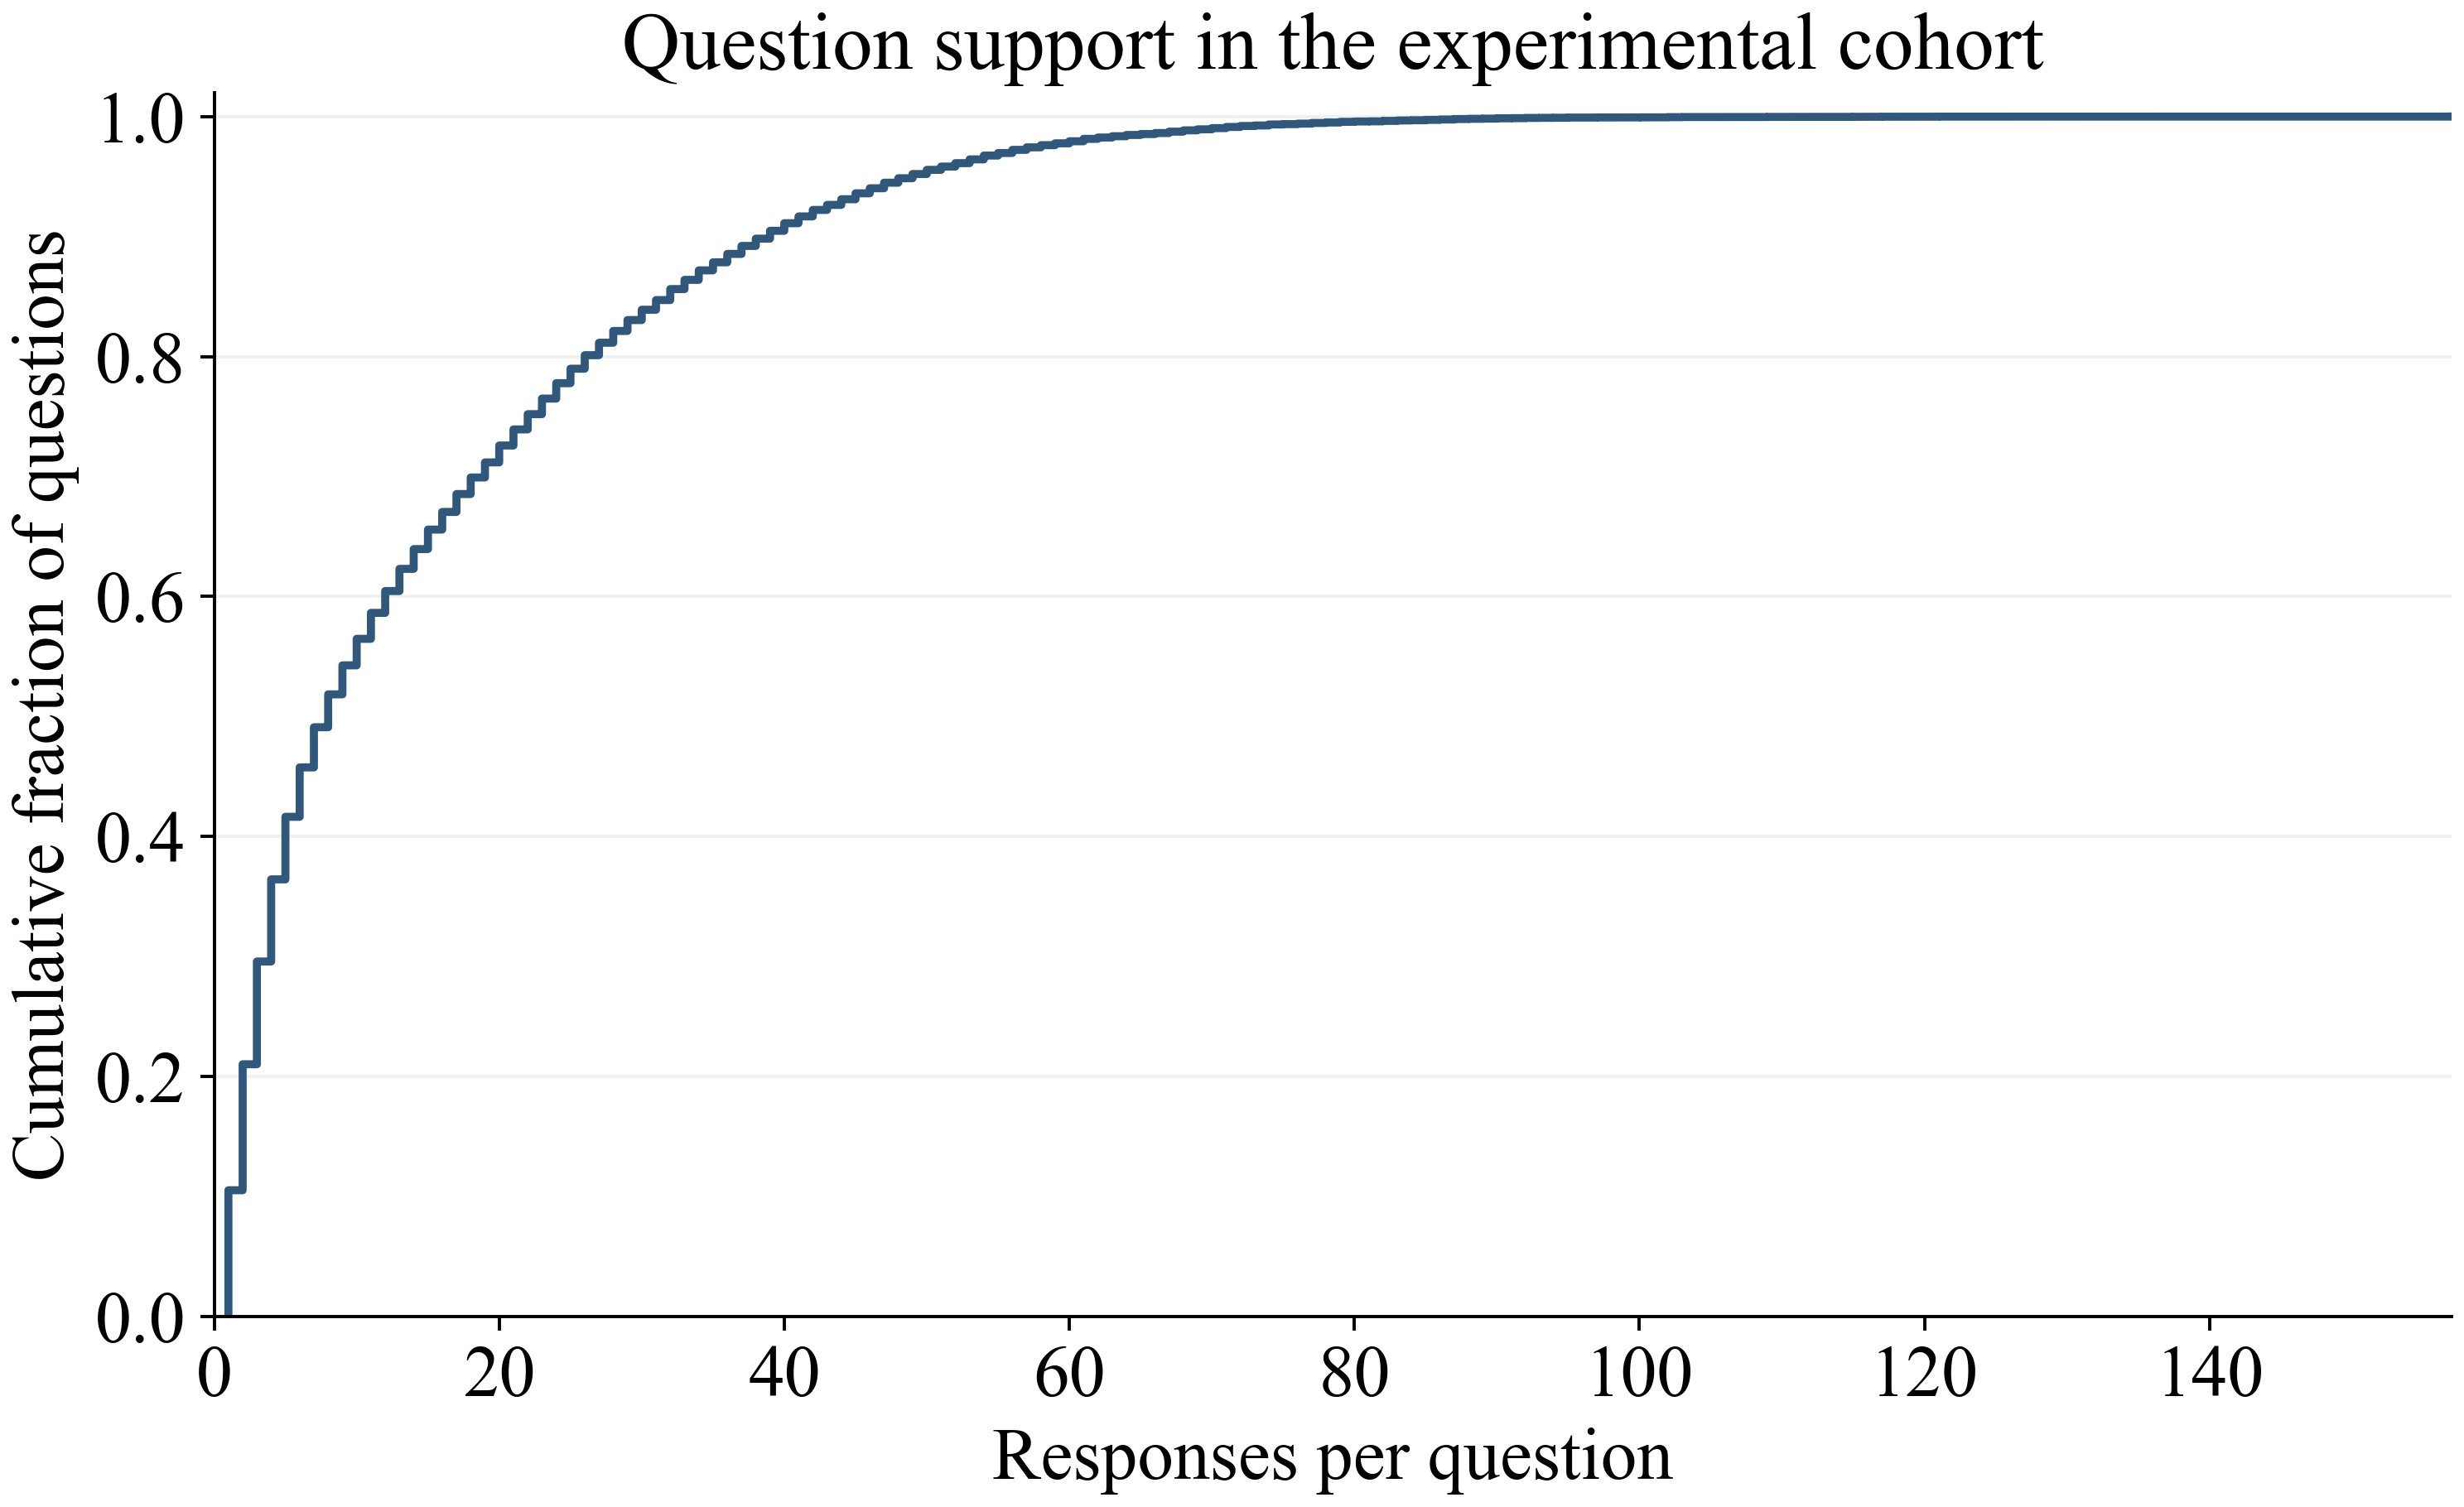

In [5]:
ordered = np.sort(question_counts.to_numpy())
fig, ax = plt.subplots(figsize=(8.5, 5.2), layout="constrained")
ax.step(ordered, np.arange(1,len(ordered)+1)/len(ordered), where="post", color="#31577A", linewidth=2)
ax.set(xlabel="Responses per question", ylabel="Cumulative fraction of questions", xlim=(0,ordered.max()), ylim=(0,1.02))
ax.set_title("Question support in the experimental cohort")
ax.spines[["top","right"]].set_visible(False); ax.grid(axis="y",alpha=.18)
save_canvas(fig,"question_support_distribution")

## Development-data quality and population structure
Expanded descriptions below are restricted to completed responses before 1 November 2019. They document data quality and observed heterogeneity; they do not change the frozen feature set, eligibility rule or model architecture.

In [4]:
cutoff=pd.Timestamp(rd.protocol()["calendar"]["outer_edges"][0],tz="UTC")
development=events[events.DateAnswered<cutoff].copy()
assert development.DateAnswered.max()<cutoff
quality=[]
for column in development:
    values=development[column]
    numeric=pd.api.types.is_numeric_dtype(values)
    quality.append({"Field":column,"Type":str(values.dtype),"Missing":int(values.isna().sum()),
        "Unique observed":int(values.nunique()),"Infinite":int(np.isinf(values.dropna().to_numpy(dtype=float)).sum()) if numeric else None})
show_table(pd.DataFrame(quality),"Development-field quality",["Field"],width=4)
valid=development.IsCorrect.isin([0,1])
assert valid.all() and development.AnswerId.is_unique
check=pd.DataFrame([{"Responses":len(development),"Learners":development.UserId.nunique(),
    "Questions":development.QuestionId.nunique(),"Start":str(development.DateAnswered.min()),
    "End":str(development.DateAnswered.max()),"Invalid binary outcomes":int((~valid).sum()),
    "Duplicate AnswerId":int(development.AnswerId.duplicated().sum()),
    "Repeated learner-question pairs":int(development.duplicated(["UserId","QuestionId"]).sum())}])
show_table(check,"Development scope and record consistency")
categorical=[]
for column in ["Gender","PremiumPupil","subject_depth"]:
    for value,n in development[column].value_counts(dropna=False).items():
        categorical.append({"Field":column,"Value":"Missing" if pd.isna(value) else str(value),"N":int(n),"Fraction":n/len(development)})
show_table(pd.DataFrame(categorical),"Development category coverage",["Field","Value"],width=2)

**Development-field quality**

Field,Type,Missing,Unique observed,Infinite
QuestionId,int64,0,23299,0
UserId,int64,0,2244,0
AnswerId,int64,0,241472,0
IsCorrect,int64,0,2,0
CorrectAnswer,int64,0,4,0
AnswerValue,int64,0,4,0
DateAnswered,"datetime64[ns, UTC]",0,114304,Not available
Confidence,float64,221628,5,0
GroupId,int64,0,2122,0
QuizId,int64,0,5183,0


**Development scope and record consistency**

Responses,Learners,Questions,Start,End
241472,2244,23299,2018-09-01 01:32:00+00:00,2019-10-31 23:18:00+00:00


Invalid binary outcomes,Duplicate AnswerId,Repeated learner-question pairs
0,0,0


**Development category coverage**

Field,Value,N,Fraction
Gender,2,102311,0.423697
Gender,1,98153,0.406478
Gender,0,40707,0.168579
Gender,3,301,0.001247
PremiumPupil,Missing,135553,0.561361
PremiumPupil,0.0,86184,0.356911
PremiumPupil,1.0,19735,0.081728
subject_depth,3.0,241381,0.999623
subject_depth,2.0,54,0.000224
subject_depth,1.0,37,0.000153


### Completion volume and outcome prevalence over time
The panels answer different questions: coverage of the development period and change in its binary target prevalence. They do not imply a causal learning effect.

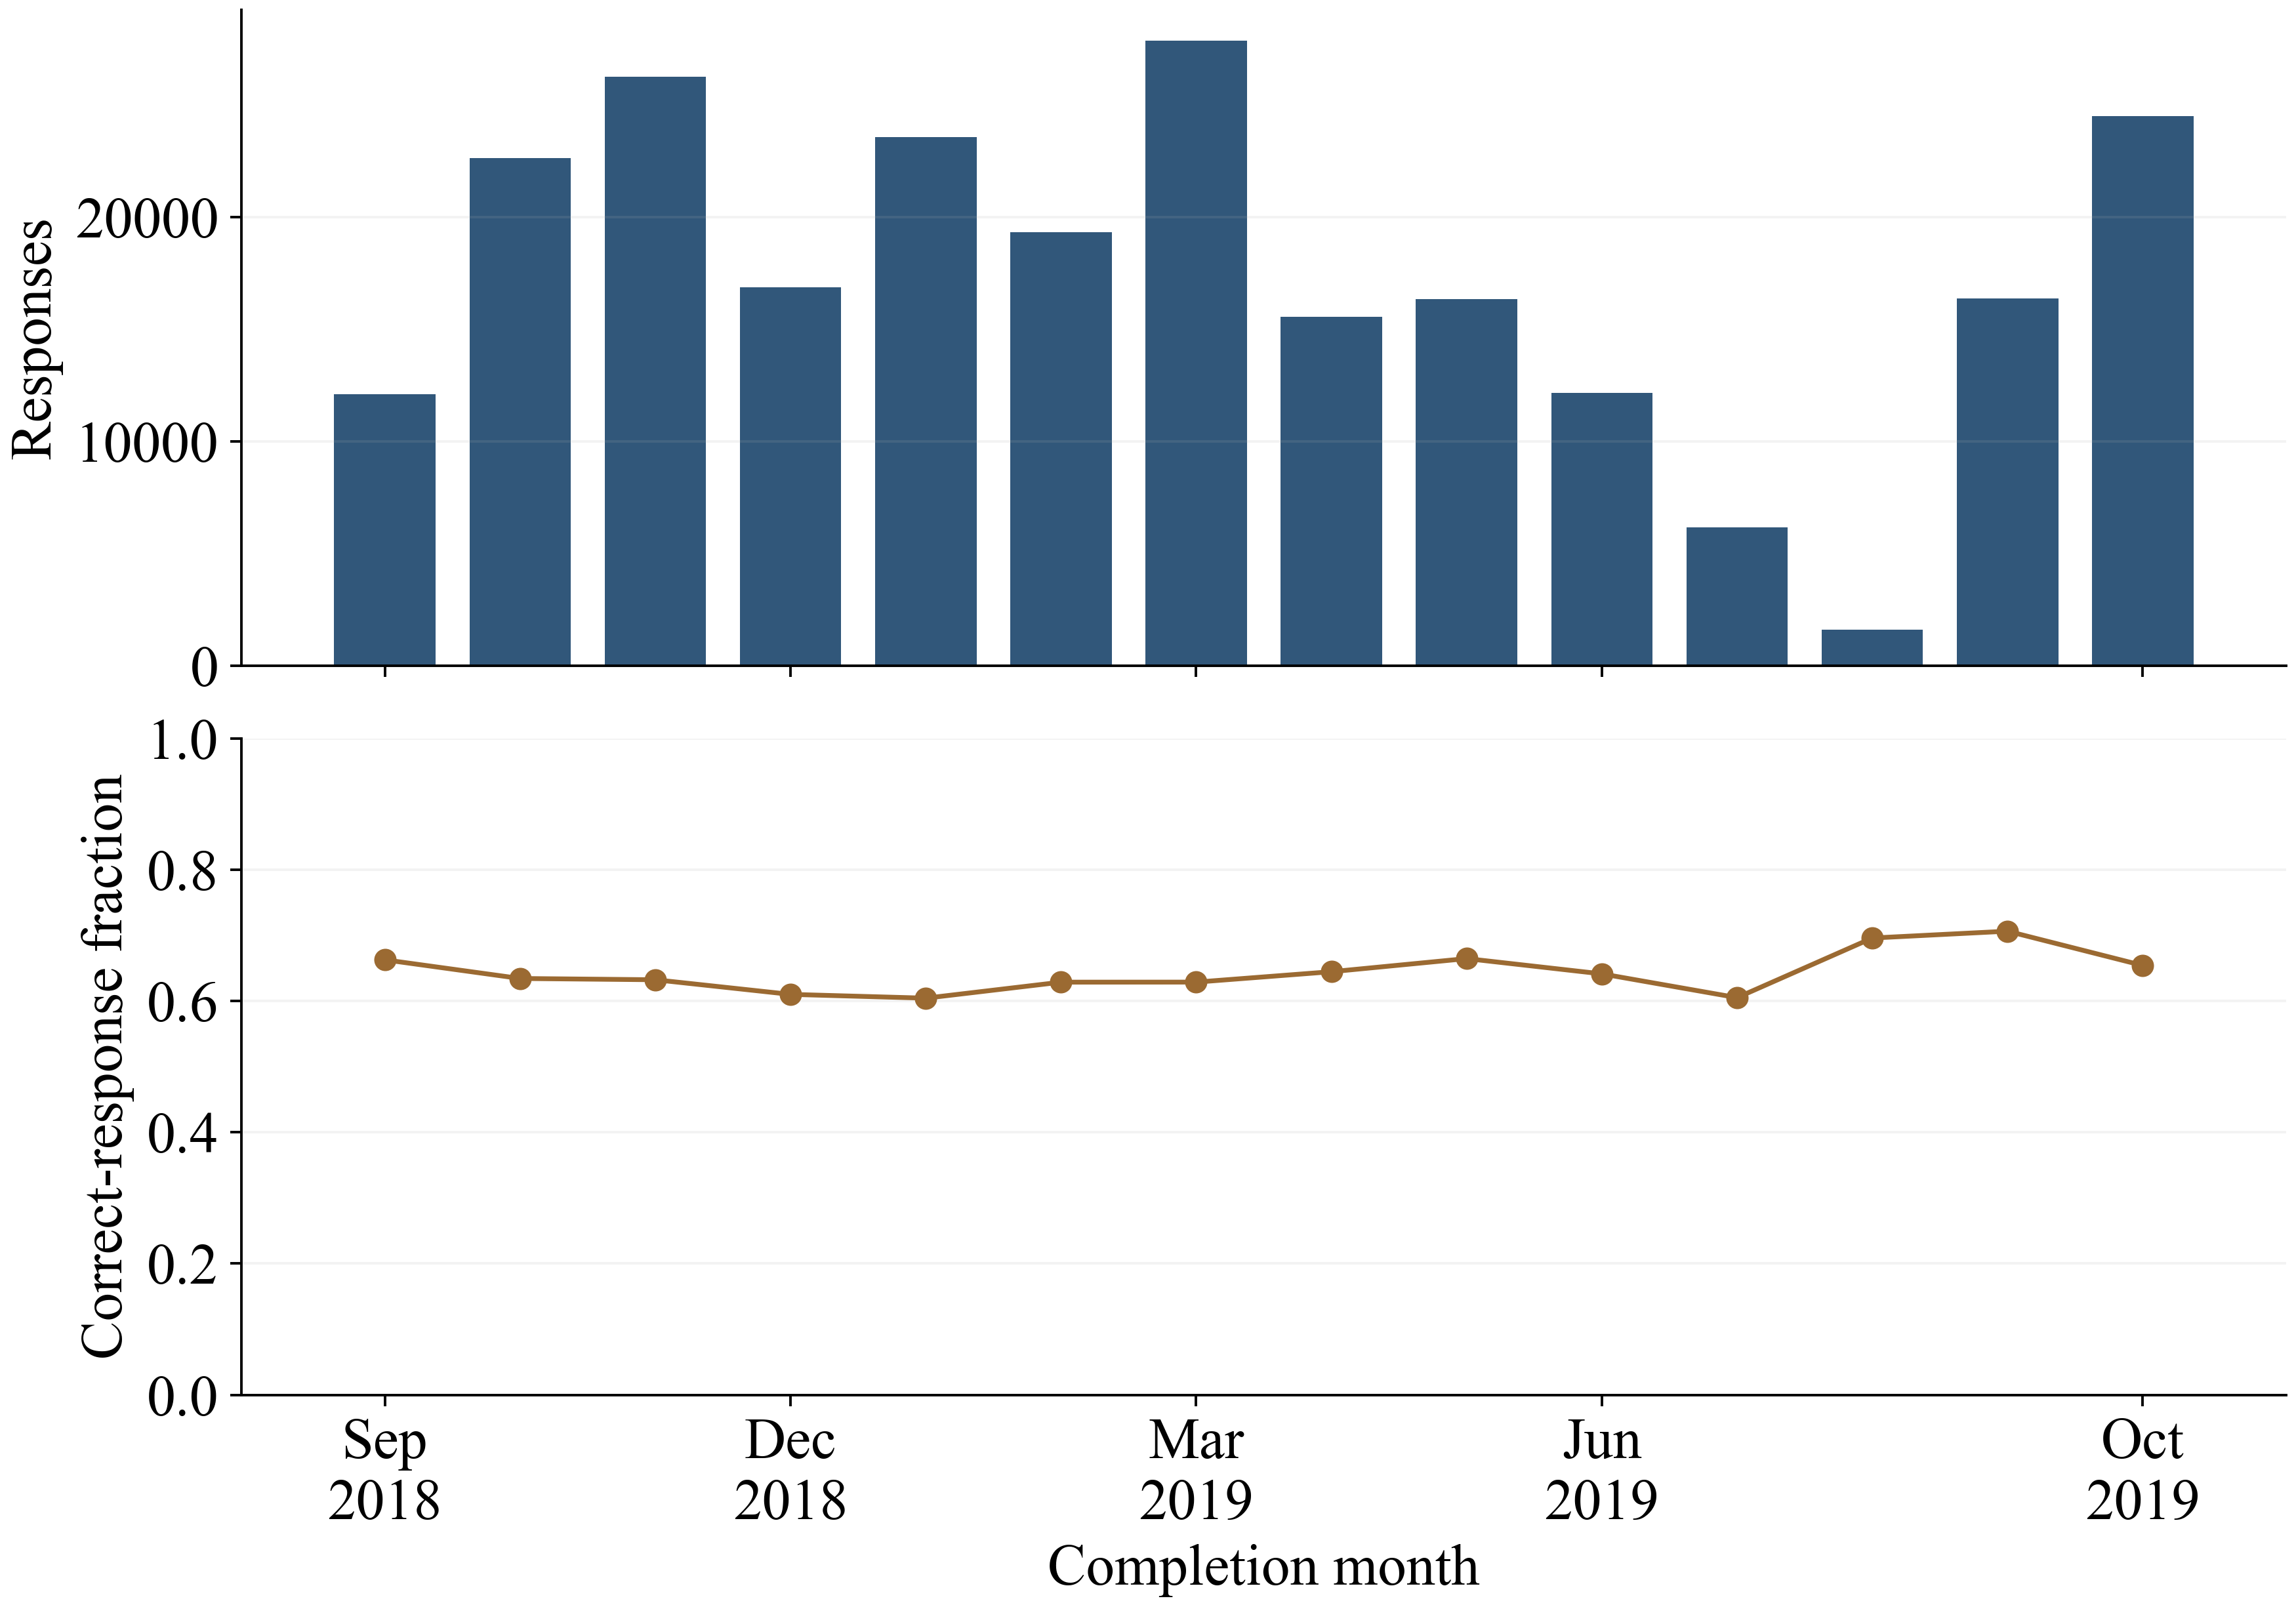

In [5]:
monthly=development.assign(Month=development.DateAnswered.dt.tz_localize(None).dt.to_period("M").astype(str)).groupby("Month").agg(N=("AnswerId","size"),Correct_fraction=("IsCorrect","mean"))
fig,axes=plt.subplots(2,1,figsize=(10,7),layout="constrained",sharex=True)
x=np.arange(len(monthly))
axes[0].bar(x,monthly.N,color="#31577A",width=.75);axes[0].set_ylabel("Responses")
axes[1].plot(x,monthly.Correct_fraction,color="#9B6A32",marker="o")
axes[1].set_ylabel("Correct-response fraction");axes[1].set_ylim(0,1)
ticks=np.unique(np.r_[0,np.arange(0,len(x),3),len(x)-1]).astype(int)
if len(ticks)>1 and ticks[-1]-ticks[-2]<2: ticks=np.delete(ticks,-2)
axes[1].set_xticks(ticks,pd.to_datetime(monthly.index[ticks]).strftime("%b\n%Y"));axes[1].set_xlabel("Completion month")
for ax in axes: ax.spines[["top","right"]].set_visible(False);ax.grid(axis="y",alpha=.15)
save_canvas(fig,"development_time_coverage")

Repeated learner-question pairs are not automatically duplicates: the response identifier defines the observation. Missing demographic values remain missing, not zero-valued groups. Long activity tails describe real exposure and are not removed as outliers. Record quality alone cannot establish the representativeness or causal independence of learners.

## Prediction-time information
Completion times establish the replay order. They do not establish when a question was presented. Current-response hour, delay, session position, confidence and answer value are therefore not predictors.

In [8]:
availability = json.loads(artifact_path("field_availability.json").read_text())
rows = [{"Field":k, "Availability":v.get("status",""), "Reason":v.get("basis","")} for k,v in availability.items() if isinstance(v,dict)]
show_table(pd.DataFrame(rows), "Information available before the response", ["Field"], width=2, rows=12)

**Information available before the response**

Field,Availability,Reason
QuestionId,pre-response,Target question identity is required by the task.
UserId,pre-response,Learner identity is required by the task.
subject_metadata,pre-response-assumption,Static content hierarchy; no version-time provenance available.
DateAnswered,post-response,Recorded answer completion timestamp; no separate presentation/prediction timestamp exists in supplied schemas.
AnswerId,unknown,"Alignment key only, never temporal tie ordering evidence."
IsCorrect,post-response,Response outcome.
AnswerValue,post-response,Chosen response.
Confidence,post-response,Response-associated confidence.
GroupId_QuizId_SchemeOfWorkId,unknown,Answer metadata; availability at prediction time not documented; excluded as current predictors.
demographics,unknown,Snapshot effective dates unknown; subgroup descriptors only.


## Interpretation and limits
The source minimum is 29 responses per learner, so the ≥20 rule removes no supplied learners. This does not supply evidence for a real low-activity population. The primary cohort contains 385,037 responses and 25,899 questions; its median question support is 8. Sparse item support motivates shrinkage, but does not by itself demonstrate a benefit from hierarchical fallback. No independent confirmatory sample or presentation timestamp is available.